### Off-Policy Methods with Approximation

Following various segments of Chapter *11* in *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [1]:
import math
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from functools import partial

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

from util.envs import GridMazeEnv, Action, State

### Baird's Counterexample

Chapter *11.3*, starting at page *260*. *Exercise 11.3*. Aimed at demonstrating weight divergence via one-step semi-gradient Q-Learning.

In [29]:
SOLID = 0
DASHED = 1

class BairdsEnv:
    def __init__(self):
        self.n_states = 7
        self.reset()

    def reset(self):
        self.state = 6  # start at bottom
        return self.state

    def step(self, action):
        if action == SOLID:
            next_state = 6
        else:  # dashed
            next_state = np.random.randint(0, 6)
        reward = 0.0
        self.state = next_state
        return next_state, reward

In [61]:
BAIRDS_FEATURES = np.array([
    [2, 0, 0, 0, 0, 0, 1, 0],  # state 0
    [0, 2, 0, 0, 0, 0, 1, 0],  # 1
    [0, 0, 2, 0, 0, 0, 1, 0],  # 2
    [0, 0, 0, 2, 0, 0, 1, 0],  # 3
    [0, 0, 0, 0, 2, 0, 1, 0],  # 4
    [0, 0, 0, 0, 0, 2, 1, 0],  # 5
    [0, 0, 0, 0, 0, 0, 1, 2]   # 6 (bottom state)
], dtype=float)


class LinearQ:
    def __init__(self):
        # Separate weights per action
        self.w = np.ones((8, 2), dtype=float) * 1.0
        self.w[-1, :] = 10.0  # bias on bottom state for both actions

    def value(self, s, a):
        return np.dot(BAIRDS_FEATURES[s], self.w[:, a])

    def grad(self, s, a):
        return BAIRDS_FEATURES[s]  # gradient w.r.t. the weights for that action

In [74]:
gamma = 0.99
alpha = 0.3
epsilon = 0.5
num_steps = 10000

actions = [SOLID, DASHED]
env = BairdsEnv()
q_vfa = LinearQ()

history = []
s = env.reset()
for step_idx in tqdm(range(num_steps)):
    
    p = np.random.random() # epsilon-greedy current action
    if p < epsilon:
        a = int(np.random.choice(actions))
    else:
        a = int(np.argmax([q_vfa.value(s, action) for action in actions]))

    s_prime, r = env.step(a)
    a_prime = int(np.argmax([q_vfa.value(s_prime, action) for action in actions])) # greedy next action

    prediction = q_vfa.value(s, a) # Q(s, a)
    target = r + gamma * q_vfa.value(s_prime, a_prime) # Q(s', a')
    delta = target - prediction
    w_update = alpha * delta * q_vfa.grad(s, a) # gradient flowing through prediction - semi-gradient
    q_vfa.w[:, a] += w_update # apply update

    s = s_prime
    history.append(q_vfa.w.copy().flatten()) # track weights


100%|██████████| 10000/10000 [00:00<00:00, 39482.08it/s]


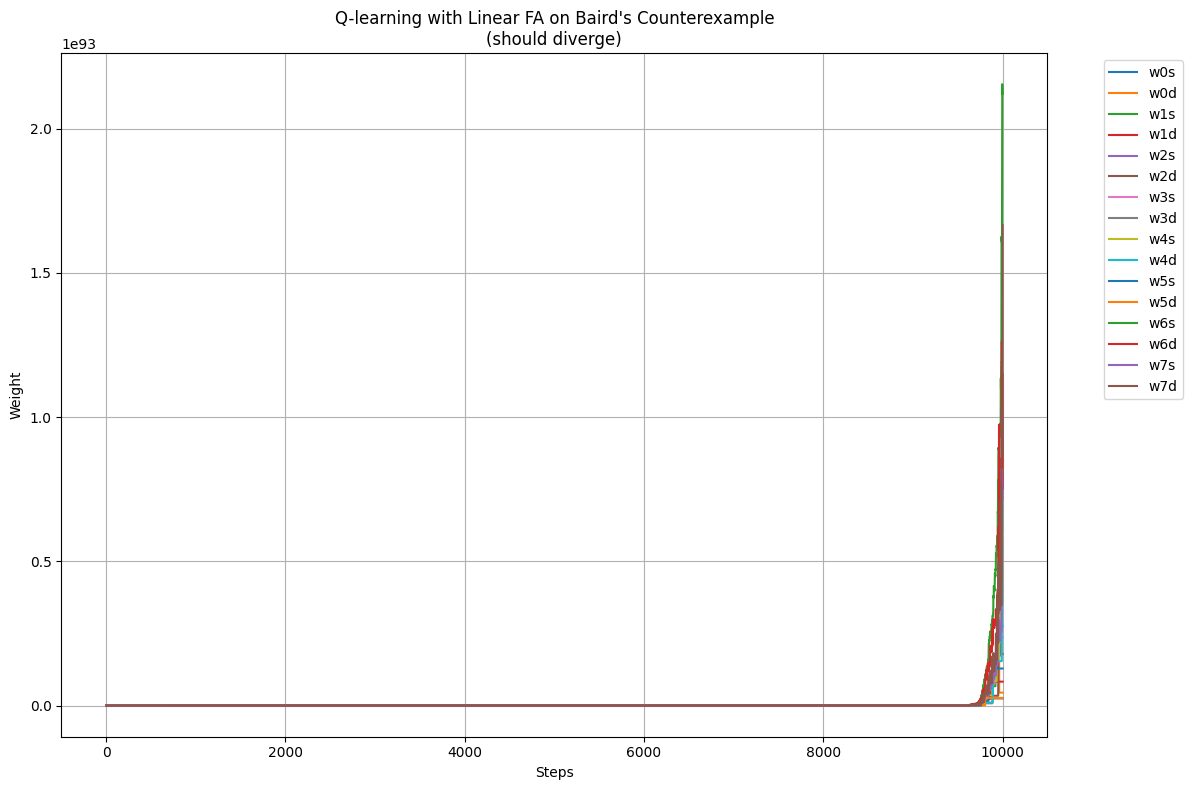

In [75]:
# Plot individual weights (flattened: w0_solid, w0_dashed, ..., w7_solid, w7_dashed)
history = np.array(history)
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.plot(history[:, i], label=f'w{i//2}{"s" if i%2==0 else "d"}')
plt.title("Q-learning with Linear FA on Baird's Counterexample\n(should diverge)")
plt.xlabel("Steps")
plt.ylabel("Weight")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()